## 1. 실험 목표와 성공 기준

이번 실험의 목표는 **`2024년 원천징수의무자를 위한 연말정산 신고안내` PDF**를 근거 문서로 활용하여, 사용자의 한국어 질문에 대해 문서 기반으로 답변하는 RAG 시스템을 구현하는 것이다. 단순히 자연스러운 답변을 생성하는 것보다, **검색된 문서의 내용에 근거하여 정확하게 응답하는 것**을 더 중요한 기준으로 삼았다.

성공 기준은 크게 세 가지로 정리하였다. 첫째, 질문과 관련된 문서를 적절하게 검색할 수 있어야 한다. 둘째, 생성된 답변이 검색 문맥과 일치해야 하며 불필요한 추측을 줄여야 한다. 셋째, 여러 질문에 대해 일관된 품질을 보이는지 정성적으로 확인할 수 있어야 한다. 따라서 이번 노트북은 성능 경쟁보다는 **문서 검색과 답변 생성의 연결 구조를 안정적으로 구현하고, 그 결과를 해석하는 것**에 초점을 두었다.


In [1]:
# STEP1_EXPERIMENT_SETUP
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

# 재현성을 위해 시드를 고정합니다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 실행 환경 기본 정보를 정리합니다.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NOTEBOOK_DIR = Path.cwd()

# 그래프에서 한글이 깨지지 않도록 가능한 폰트를 우선 설정합니다.
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break
plt.rcParams['axes.unicode_minus'] = False

experiment_goal_df = pd.DataFrame(
    [
        {'항목': '과제 목표', '내용': '연말정산 안내 PDF를 근거로 한국어 질문에 답하는 RAG 시스템 구현'},
        {'항목': '핵심 검증', '내용': '검색된 문서가 적절한지와 답변이 문서 내용에 맞는지 확인'},
        {'항목': '심화 범위', '내용': '기본 RAG 완성 후 개선 검색 설정 1개 비교'},
    ]
)
display(experiment_goal_df)

print(f'현재 작업 경로: {NOTEBOOK_DIR}')
print(f'사용 장치: {DEVICE}')
print(f'PyTorch 버전: {torch.__version__}')


,항목,내용
0,과제 목표,연말정산 안내 PDF를 근거로 한국어 질문에 답하는 RAG 시스템 구현
1,핵심 검증,검색된 문서가 적절한지와 답변이 문서 내용에 맞는지 확인
2,심화 범위,기본 RAG 완성 후 개선 검색 설정 1개 비교


현재 작업 경로: c:\Users\amy\Desktop\sprint\sprint_ai07\미션
사용 장치: cuda
PyTorch 버전: 2.9.1+cu126


## 2. 문서와 과제 범위 정의

이번 과제에서는 국세청 연말정산 안내 PDF 한 개를 중심으로 RAG 시스템을 구성하였다. 이 문서는 연말정산 절차, 공제 항목, 개정 세법, 제출 시 유의사항 등 다양한 정보를 포함하고 있어 질문 응답형 실험에 적합하다. 또한 페이지 수가 많고 정보 밀도가 높아, RAG의 핵심인 **문서 검색 품질과 문맥 기반 답변 생성 성능**을 확인하기에 좋은 자료라고 판단했다.

과제 범위는 먼저 **기본 RAG 파이프라인을 완성하는 것**으로 설정하였다. 이후 같은 질문 세트에 대해 검색 방식을 일부 조정한 개선 실험을 한 가지 추가하여, 설정 변화가 검색 결과와 답변 품질에 어떤 영향을 주는지 비교하고자 했다. 즉, 이번 실험은 복잡한 고급 기법을 많이 적용하기보다 **기본 구조를 명확히 구현하고 비교 가능한 실험을 만드는 것**을 목표로 한다.


In [2]:
# STEP2_SCOPE_AND_PATHS
required_vars = ['NOTEBOOK_DIR', 'DEVICE', 'display', 'pd']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 이번 미션에서 사용할 주요 설정값을 한곳에 모읍니다.
MISSION_NAME = 'mission14_rag'
PDF_FILE_HINT = '연말정산'
MANUAL_PDF_PATH = None  # 예: '/content/2024년_연말정산_안내.pdf'
EMBEDDING_MODEL_NAME = 'nlpai-lab/KoE5'
LLM_MODEL_NAME = 'Qwen/Qwen2.5-3B-Instruct'

BASE_CHUNK_SIZE = 900
BASE_CHUNK_OVERLAP = 120
BASE_TOP_K = 4

IMPROVED_RETRIEVAL_NAME = 'mmr'
IMPROVED_TOP_K = 5
IMPROVED_FETCH_K = 12

TEMPERATURE = 0.2
REPETITION_PENALTY = 1.1
MAX_NEW_TOKENS = 384
ENABLE_4BIT = True

# PDF 파일 경로를 자동 탐색하되, 필요하면 MANUAL_PDF_PATH로 직접 지정할 수 있습니다.
pdf_candidates = []
if MANUAL_PDF_PATH:
    pdf_candidates.append(Path(MANUAL_PDF_PATH))

pdf_candidates.extend([
    NOTEBOOK_DIR / 'content' / '2024년+원천징수의무자를+위한+연말정산+신고안내.pdf',
    NOTEBOOK_DIR / '미션' / 'content' / '2024년+원천징수의무자를+위한+연말정산+신고안내.pdf',
])

pdf_candidates.extend(sorted(Path('.').rglob('*연말정산*안내*.pdf')))
pdf_candidates.extend(sorted(Path('.').rglob('*연말정산*.pdf')))

PDF_PATH = next((candidate for candidate in pdf_candidates if candidate.exists()), None)
if PDF_PATH is None:
    raise FileNotFoundError('연말정산 PDF 파일을 찾지 못했습니다. MANUAL_PDF_PATH를 확인해 주세요.')

OUTPUT_DIR = NOTEBOOK_DIR / 'outputs' / MISSION_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scope_config_df = pd.DataFrame(
    [
        {'설정': '문서 경로', '값': str(PDF_PATH)},
        {'설정': '임베딩 모델', '값': EMBEDDING_MODEL_NAME},
        {'설정': '생성 모델', '값': LLM_MODEL_NAME},
        {'설정': '기본 청크 설정', '값': f'chunk_size={BASE_CHUNK_SIZE}, overlap={BASE_CHUNK_OVERLAP}'},
        {'설정': '기본 검색 설정', '값': f'similarity top_k={BASE_TOP_K}'},
        {'설정': '개선 검색 설정', '값': f'{IMPROVED_RETRIEVAL_NAME}, k={IMPROVED_TOP_K}, fetch_k={IMPROVED_FETCH_K}'},
    ]
)
display(scope_config_df)
print(f'산출물 저장 폴더: {OUTPUT_DIR}')


,설정,값
0,문서 경로,c:\Users\amy\Desktop\sprint\sprint_ai07\미션\con...
1,임베딩 모델,nlpai-lab/KoE5
2,생성 모델,Qwen/Qwen2.5-3B-Instruct
3,기본 청크 설정,"chunk_size=900, overlap=120"
4,기본 검색 설정,similarity top_k=4
5,개선 검색 설정,"mmr, k=5, fetch_k=12"


산출물 저장 폴더: c:\Users\amy\Desktop\sprint\sprint_ai07\미션\outputs\mission14_rag


## 3. 전체 파이프라인 개요

전체 파이프라인은 다음과 같은 순서로 구성하였다. 먼저 PDF 문서를 페이지 단위로 불러오고, 이후 검색에 적합한 크기의 청크로 분할한다. 다음으로 각 청크를 임베딩 벡터로 변환하여 벡터 데이터베이스에 저장하고, 사용자의 질문이 들어오면 retriever가 관련 청크를 검색하도록 설정하였다. 마지막으로 검색된 문맥을 프롬프트에 넣어 언어 모델이 최종 답변을 생성하도록 구성하였다.

정리하면 본 노트북의 흐름은 **문서 로드 -> 청킹 -> 임베딩 -> 벡터DB 구성 -> retriever 설정 -> LLM 연결 -> RAG 체인 구성 -> 질문 평가**의 순서이다. 이와 같은 단계적 구성을 통해 각 부분이 어떤 역할을 하는지 확인하고, 나중에 개선 실험에서도 어느 지점을 조정했는지 분명하게 비교할 수 있도록 했다.


In [3]:
# STEP3_PIPELINE_OVERVIEW
required_vars = ['PDF_PATH', 'OUTPUT_DIR', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~2번 셀을 먼저 실행하세요. 누락 변수: {missing}')

pipeline_stage_df = pd.DataFrame(
    [
        {'단계': 1, '이름': '문서 로드', '입력': 'PDF 파일', '출력': '페이지 단위 문서 리스트'},
        {'단계': 2, '이름': '문서 청킹', '입력': '페이지 문서', '출력': '검색 가능한 청크'},
        {'단계': 3, '이름': '임베딩 생성', '입력': '청크', '출력': '벡터 표현'},
        {'단계': 4, '이름': '벡터DB 저장', '입력': '임베딩', '출력': 'retriever'},
        {'단계': 5, '이름': 'LLM 연결', '입력': '질문 + 검색 문맥', '출력': '최종 답변'},
        {'단계': 6, '이름': '평가', '입력': '질문 세트', '출력': '질문별 응답과 정성 평가'},
    ]
)
display(pipeline_stage_df)


,단계,이름,입력,출력
0,1,문서 로드,PDF 파일,페이지 단위 문서 리스트
1,2,문서 청킹,페이지 문서,검색 가능한 청크
2,3,임베딩 생성,청크,벡터 표현
3,4,벡터DB 저장,임베딩,retriever
4,5,LLM 연결,질문 + 검색 문맥,최종 답변
5,6,평가,질문 세트,질문별 응답과 정성 평가


## 4. 실행 환경과 라이브러리 준비

이번 실험은 Hugging Face와 LangChain 기반으로 구성하였다. PDF 로드는 `PyPDFLoader`, 문서 분할은 `RecursiveCharacterTextSplitter`, 임베딩과 LLM 연결은 LangChain 래퍼를 활용했고, 벡터 데이터베이스는 구현이 간단하고 실험용으로 적합한 `FAISS`를 사용하였다. 이러한 조합은 실험용 노트북에서 비교적 빠르게 전체 RAG 흐름을 확인할 수 있다는 장점이 있다.

또한 생성 모델을 로컬 또는 노트북 환경에서 실행해야 하므로, 메모리 부담을 줄이기 위한 양자화 옵션도 함께 고려하였다. 이번 과제에서는 최신 대규모 시스템을 복잡하게 붙이기보다, **재현 가능한 환경에서 기본 RAG 구조를 안정적으로 실행하고 결과를 해석하는 것**을 우선하였다.


In [4]:
# STEP4_ENV_AND_IMPORTS
# 필요하다면 아래 설치 명령의 주석을 해제한 뒤 한 번만 실행하세요.
# %pip install -q langchain-core langchain-community langchain-text-splitters langchain-huggingface faiss-cpu pypdf sentence-transformers accelerate bitsandbytes transformers

import importlib.util
from importlib.metadata import PackageNotFoundError, version

required_vars = ['PDF_PATH', 'DEVICE', 'display', 'pd', 'torch']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~3번 셀을 먼저 실행하세요. 누락 변수: {missing}')

REQUIRED_PACKAGES = [
    {'표시명': 'langchain-core', '모듈명': 'langchain_core', '배포명': 'langchain-core'},
    {'표시명': 'langchain-community', '모듈명': 'langchain_community', '배포명': 'langchain-community'},
    {'표시명': 'langchain-text-splitters', '모듈명': 'langchain_text_splitters', '배포명': 'langchain-text-splitters'},
    {'표시명': 'langchain-huggingface', '모듈명': 'langchain_huggingface', '배포명': 'langchain-huggingface'},
    {'표시명': 'faiss-cpu', '모듈명': 'faiss', '배포명': 'faiss-cpu'},
    {'표시명': 'pypdf', '모듈명': 'pypdf', '배포명': 'pypdf'},
    {'표시명': 'sentence-transformers', '모듈명': 'sentence_transformers', '배포명': 'sentence-transformers'},
    {'표시명': 'transformers', '모듈명': 'transformers', '배포명': 'transformers'},
]
OPTIONAL_PACKAGES = [
    {'표시명': 'bitsandbytes', '모듈명': 'bitsandbytes', '배포명': 'bitsandbytes'},
]


def get_package_status(module_name, distribution_name):
    installed = importlib.util.find_spec(module_name) is not None
    if not installed:
        return False, None
    try:
        return True, version(distribution_name)
    except PackageNotFoundError:
        return True, '설치됨(버전 확인 불가)'


package_rows = []
for pkg in REQUIRED_PACKAGES + OPTIONAL_PACKAGES:
    installed, version_text = get_package_status(pkg['모듈명'], pkg['배포명'])
    package_rows.append(
        {
            '패키지': pkg['표시명'],
            '모듈': pkg['모듈명'],
            '설치 여부': installed,
            '버전': version_text,
            '필수 여부': '필수' if pkg in REQUIRED_PACKAGES else '선택',
        }
    )

env_df = pd.DataFrame(package_rows)
display(env_df)

missing_required = env_df[(env_df['필수 여부'] == '필수') & (~env_df['설치 여부'])]['패키지'].tolist()
if missing_required:
    raise ModuleNotFoundError(
        '다음 패키지가 설치되어 있지 않습니다: '
        + ', '.join(missing_required)
        + chr(10)
        + '필요하면 위 설치 명령을 먼저 실행하세요.'
    )

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

HF_TORCH_DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32
print('LangChain 및 Hugging Face 관련 라이브러리 import 완료')


,패키지,모듈,설치 여부,버전,필수 여부
0,langchain-core,langchain_core,True,1.2.22,필수
1,langchain-community,langchain_community,True,0.4.1,필수
2,langchain-text-splitters,langchain_text_splitters,True,1.1.1,필수
3,langchain-huggingface,langchain_huggingface,True,1.2.1,필수
4,faiss-cpu,faiss,True,1.13.2,필수
5,pypdf,pypdf,True,6.9.2,필수
6,sentence-transformers,sentence_transformers,True,5.2.3,필수
7,transformers,transformers,True,5.3.0,필수
8,bitsandbytes,bitsandbytes,False,None,선택


c:\Users\amy\Desktop\sprint\sprint_ai07\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LangChain 및 Hugging Face 관련 라이브러리 import 완료


## 5. 원본 문서 로드 전략

원본 PDF는 전체를 하나의 문자열로 합치는 대신 **페이지 단위 문서 객체로 로드**하였다. 이렇게 하면 각 페이지의 내용을 분리해서 다룰 수 있고, 이후 검색 결과가 어느 페이지에서 왔는지 메타데이터를 통해 추적하기 쉬워진다. 특히 RAG 실험에서는 답변의 근거를 확인하는 과정이 중요하므로, 페이지 번호 정보는 결과 해석에 큰 도움이 된다.

또한 페이지 단위 로드는 이후 청킹 단계에서도 유리하다. 너무 긴 문서를 한꺼번에 나누는 방식보다, 페이지별로 쪼개진 문서를 다시 청크로 분할하면 문맥 경계를 어느 정도 보존할 수 있기 때문이다. 따라서 이번 실험에서는 **검색 정확도와 근거 확인 가능성**을 고려하여 페이지 단위 로드 전략을 채택했다.


In [5]:
# STEP5_DOCUMENT_LOAD
required_vars = ['PDF_PATH', 'PyPDFLoader', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~4번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# PDF 문서를 페이지 단위로 불러옵니다.
pdf_loader = PyPDFLoader(str(PDF_PATH))
pages = pdf_loader.load()
TOTAL_PAGE_COUNT = len(pages)


def get_page_label(doc):
    page_label = doc.metadata.get('page_label')
    if page_label is not None:
        return page_label
    page_index = doc.metadata.get('page')
    if page_index is None:
        return '?'
    return page_index + 1


def shorten_text(text, max_chars=160):
    compact = ' '.join(str(text).split())
    return compact if len(compact) <= max_chars else compact[:max_chars] + '...'


page_rows = []
for idx, page in enumerate(pages[:10], start=1):
    page_rows.append(
        {
            '페이지': get_page_label(page),
            '문자 수': len(page.page_content),
            '미리보기': shorten_text(page.page_content, 140),
        }
    )

page_preview_df = pd.DataFrame(page_rows)
display(page_preview_df)
print(f'불러온 전체 페이지 수: {TOTAL_PAGE_COUNT:,}')
print(f'PDF 파일명: {PDF_PATH.name}')


,페이지,문자 수,미리보기
0,1,116,"연말정산 신고안내 일 하나는 제대로 하는, 국민께 인정받는 국세청 2024. 12...."
1,2,672,머 리 말 어려운 경제 상황 속에서도 항상 성실하게 원천징수의무를 이행하여 국세행정...
2,3,1364,국세청 연말정산 서비스 이용자 서비스 내 용 접근 경로 공통 원천징수(연말정산)안내...
3,4,1468,고용관계 또는 이와 유사한 계약에 의하여 근로를 제공하고 지급받는 모든 대가 등 (...
4,5,1551,"공적연금(국민연금, 공무원연금, 군인연금, 사립학교교직원연금, 별정우체국연금, 국민..."
5,6,1883,( = 근로소득금액 - 인적공제 - 연금보험료공제 - 특별소득공제 - 그 밖의 소득...
6,7,1450,교육비 세액공제(세액공제율 : 15% ) 근로자 본인을 위해 대학·대학원 1학기 이...
7,8,1205,연말정산 소득·세액공제 요건표 구 분 공 제 요 건 비 고 나이요건* 소득요건* 동...
8,9,912,「간소화 서비스 전면개편」 주요 내용 「간소화자료 일괄제공 서비스」 이용을 희망하는...
9,10,983,연말정산 과다공제 유형 항목 과다공제 사례  소득금액 기준(1백만 원) 초과 부양...


불러온 전체 페이지 수: 426
PDF 파일명: 2024년+원천징수의무자를+위한+연말정산+신고안내.pdf


## 6. 문서 전처리와 청킹 기준

문서 청킹은 RAG 성능에 직접적인 영향을 주는 핵심 단계이므로, 이번 실험에서는 먼저 **문자 기반 분할 방식**을 사용해 기본 구조를 만들었다. `chunk_size=900`, `chunk_overlap=120`으로 설정한 이유는, 한 청크 안에 너무 적은 정보만 담기면 검색 문맥이 부족해지고, 반대로 너무 길어지면 검색 정확도가 떨어질 수 있기 때문이다. 겹침 구간을 둔 것은 문장이 청크 경계에서 잘리는 문제를 완화하기 위해서이다.

이번 설정은 완벽한 최적값이라기보다, **검색 정확도와 문맥 보존 사이의 균형을 고려한 출발점**으로 볼 수 있다. 이후 필요하다면 chunk size를 줄이거나 overlap을 늘리는 방식으로 추가 실험이 가능하며, 문서 구조를 더 정교하게 반영한 분할 방식으로 확장할 여지도 있다.


In [6]:
# STEP6_CHUNKING
required_vars = ['pages', 'RecursiveCharacterTextSplitter', 'BASE_CHUNK_SIZE', 'BASE_CHUNK_OVERLAP']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~5번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 기본 실험용 청킹 설정을 정의합니다.
base_text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=BASE_CHUNK_SIZE,
    chunk_overlap=BASE_CHUNK_OVERLAP,
    separators=[chr(10) * 2, chr(10), '. ', ' ', ''],
    length_function=len,
)
base_chunks = base_text_splitter.split_documents(pages)
BASE_CHUNK_COUNT = len(base_chunks)

chunking_config_df = pd.DataFrame(
    [
        {'항목': 'chunk_size', '값': BASE_CHUNK_SIZE},
        {'항목': 'chunk_overlap', '값': BASE_CHUNK_OVERLAP},
        {'항목': '총 청크 수', '값': BASE_CHUNK_COUNT},
    ]
)
display(chunking_config_df)
print('기본 청킹이 완료되었습니다.')


,항목,값
0,chunk_size,900
1,chunk_overlap,120
2,총 청크 수,696


기본 청킹이 완료되었습니다.


## 7. 청킹 결과 점검

청킹이 끝난 뒤에는 총 청크 수와 각 청크 길이 분포를 확인하여, 설정이 지나치게 공격적이거나 비효율적이지 않은지 점검하였다. 이 과정은 단순 확인처럼 보이지만 매우 중요하다. 청크가 너무 짧으면 검색 시 의미 있는 문맥이 끊어질 수 있고, 반대로 너무 길면 질문과 직접 관련 없는 정보까지 함께 들어가 검색 품질이 흔들릴 수 있기 때문이다.

아래 표와 그래프는 현재 설정에서 생성된 청크들이 어느 정도 길이를 가지는지 보여준다. 또한 일부 청크 미리보기를 함께 확인함으로써, 실제로 문단 단위 정보가 자연스럽게 잘려 있는지, 특정 페이지에서 불필요하게 짧거나 긴 청크가 발생하지 않는지도 함께 살펴보았다. 이 점검 단계를 통해 이후 임베딩과 검색 단계로 넘어가도 되는지 판단할 수 있다.


,청크 ID,페이지,문자 수,미리보기
0,0,1,116,"연말정산 신고안내 일 하나는 제대로 하는, 국민께 인정받는 국세청 2024. 12...."
1,1,2,672,머 리 말 어려운 경제 상황 속에서도 항상 성실하게 원천징수의무를 이행하여 국세행정...
2,2,3,889,국세청 연말정산 서비스 이용자 서비스 내 용 접근 경로 공통 원천징수(연말정산)안내...
3,3,3,576,안내책자 및 영상 「근로자를 위한 연말정산 안내」 책자 「근로자를 위한 연말정산」 ...
4,4,4,853,고용관계 또는 이와 유사한 계약에 의하여 근로를 제공하고 지급받는 모든 대가 등 (...
5,5,4,681,"4,500만원 초과 1억원 이하 1,200만원 + 4,500만원 초과액의 5% 총급..."
6,6,5,891,"공적연금(국민연금, 공무원연금, 군인연금, 사립학교교직원연금, 별정우체국연금, 국민..."
7,7,5,761,"초과할 수 없음) 신용카드 등 사용금액 : 신용카드, 직불카드, 선불카드, 현금영수..."
8,8,6,855,( = 근로소득금액 - 인적공제 - 연금보험료공제 - 특별소득공제 - 그 밖의 소득...
9,9,6,855,단절여성이 중소기업 에 취업하는 경우 취업일로부터 3년간(청년 5년간) 근로소득세 ...


,count,mean,std,min,25%,50%,75%,max
문자 수,696.0,606.91954,289.733024,3.0,335.0,722.5,874.25,900.0


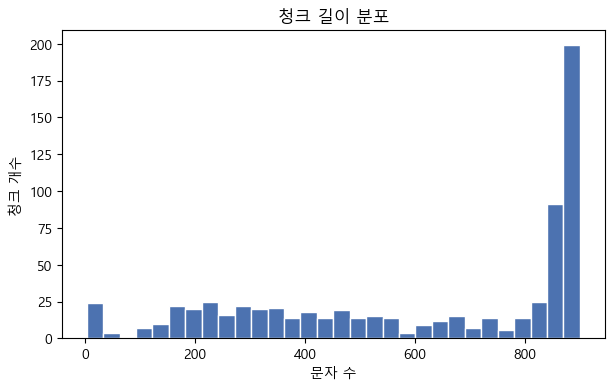

In [7]:
# STEP7_CHUNK_INSPECTION
required_vars = ['base_chunks', 'get_page_label', 'shorten_text', 'pd', 'plt']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~6번 셀을 먼저 실행하세요. 누락 변수: {missing}')

chunk_rows = []
for idx, doc in enumerate(base_chunks):
    chunk_rows.append(
        {
            '청크 ID': idx,
            '페이지': get_page_label(doc),
            '문자 수': len(doc.page_content),
            '미리보기': shorten_text(doc.page_content, 140),
        }
    )

chunk_stats_df = pd.DataFrame(chunk_rows)
display(chunk_stats_df.head(10))
display(chunk_stats_df[['문자 수']].describe().T)

ax = chunk_stats_df['문자 수'].plot(
    kind='hist',
    bins=30,
    figsize=(7, 4),
    color='#4c72b0',
    edgecolor='white',
)
ax.set_title('청크 길이 분포')
ax.set_xlabel('문자 수')
ax.set_ylabel('청크 개수')
plt.show()


## 8. 임베딩 모델 선택 이유

이번 실험에서는 한국어 문서 검색에 적합한 임베딩 모델로 `nlpai-lab/KoE5`를 사용하였다. 연말정산 안내 문서는 한국어 중심의 행정·설명 문서이므로, 영어 위주의 일반 임베딩 모델보다 **한국어 의미 유사도를 안정적으로 반영할 수 있는 모델**이 더 적합하다고 보았다. 또한 임베딩 모델은 생성 모델과 달리 검색 품질에 직접적인 영향을 주기 때문에, 문서와 질문의 의미적 유사성을 잘 잡아내는지가 중요하다.

이 모델을 선택한 또 다른 이유는 실험용 노트북 환경에서 비교적 사용하기 수월하다는 점이다. 지나치게 큰 모델을 쓰면 임베딩 생성 시간이 길어지고 자원 부담이 커질 수 있는데, 이번 과제에서는 고성능 경쟁보다 **실행 가능성과 검색 품질의 균형**을 우선하였다. 따라서 KoE5는 한국어 RAG 실험의 기본 모델로 적절하다고 판단했다.


In [8]:
# STEP8_EMBEDDING_SETUP
required_vars = ['EMBEDDING_MODEL_NAME', 'HuggingFaceEmbeddings', 'DEVICE', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~7번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 한국어 문서 검색에 사용할 임베딩 모델을 준비합니다.
embedding_model_kwargs = {'device': DEVICE if DEVICE == 'cuda' else 'cpu'}
embedding_encode_kwargs = {'normalize_embeddings': True}

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs=embedding_model_kwargs,
    encode_kwargs=embedding_encode_kwargs,
)

sample_embedding = embeddings.embed_query('연말정산 안내 문서 검색 테스트')
embedding_info_df = pd.DataFrame(
    [
        {'항목': '임베딩 모델', '값': EMBEDDING_MODEL_NAME},
        {'항목': '임베딩 차원', '값': len(sample_embedding)},
        {'항목': '정규화 사용', '값': embedding_encode_kwargs['normalize_embeddings']},
    ]
)
display(embedding_info_df)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2567.73it/s]


,항목,값
0,임베딩 모델,nlpai-lab/KoE5
1,임베딩 차원,1024
2,정규화 사용,True


## 9. 벡터 데이터베이스 구성

청크를 임베딩 벡터로 변환한 뒤에는 이를 빠르게 검색할 수 있도록 벡터 데이터베이스에 저장해야 한다. 이번 실험에서는 `FAISS`를 사용해 벡터 저장소를 구성하였다. FAISS는 실험 단계에서 설정이 비교적 단순하고, 로컬 환경에서도 빠르게 검색 인덱스를 만들 수 있어 RAG 프로토타입에 적합하다.

이번 과제의 목적은 서비스 배포용 대규모 인프라를 구축하는 것이 아니라, 문서 검색이 실제로 작동하는 흐름을 확인하는 것이므로 FAISS 선택은 충분히 합리적이다. 또한 같은 청크와 같은 임베딩을 사용한 상태에서 retriever 설정만 변경해 비교하기에도 편리하다는 장점이 있다. 따라서 본 실험에서는 **간단하면서도 안정적인 벡터 검색 환경**을 만드는 데 초점을 맞추었다.


In [9]:
# STEP9_VECTOR_STORE_BUILD
required_vars = ['base_chunks', 'embeddings', 'FAISS', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~8번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 청크 임베딩을 벡터 데이터베이스에 저장합니다.
vector_store = FAISS.from_documents(documents=base_chunks, embedding=embeddings)
VECTOR_DOC_COUNT = len(getattr(vector_store.docstore, '_dict', {}))

vector_store_info_df = pd.DataFrame(
    [
        {'항목': '벡터 저장 방식', '값': 'FAISS'},
        {'항목': '저장된 문서 수', '값': VECTOR_DOC_COUNT},
        {'항목': '임베딩 모델', '값': EMBEDDING_MODEL_NAME},
    ]
)
display(vector_store_info_df)
print('벡터 데이터베이스 구성이 완료되었습니다.')


,항목,값
0,벡터 저장 방식,FAISS
1,저장된 문서 수,696
2,임베딩 모델,nlpai-lab/KoE5


벡터 데이터베이스 구성이 완료되었습니다.


## 10. Retriever 설정과 검색 기준

retriever는 사용자의 질문과 가장 관련 있는 문서를 골라내는 역할을 하므로, RAG 품질을 좌우하는 핵심 구성 요소 중 하나이다. 기본 실험에서는 `similarity` 검색 방식을 사용하고, 상위 `top-k=4`개의 문서를 가져오도록 설정하였다. 이 값은 너무 적으면 필요한 근거를 놓칠 수 있고, 너무 많으면 불필요한 문맥이 섞여 답변 품질이 떨어질 수 있다는 점을 고려한 선택이다.

즉, 이번 기본 설정은 질문에 대해 **핵심 근거를 적당한 수만큼 가져오는 것**을 목표로 한 값이라고 볼 수 있다. 이후 개선 실험에서는 이 검색 방식을 바꾸거나 가져오는 문서 수를 조정하여, 문서 다양성과 검색 적합성이 실제 답변에 어떤 차이를 만드는지 비교해보고자 한다.


In [10]:
# STEP10_RETRIEVER_SETUP
required_vars = ['vector_store', 'BASE_TOP_K', 'get_page_label', 'shorten_text', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~9번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 기본 검색기는 유사도 기준으로 상위 문서를 가져오도록 설정합니다.
base_retriever = vector_store.as_retriever(
    search_type='similarity',
    search_kwargs={'k': BASE_TOP_K},
)


def docs_to_preview_df(docs):
    rows = []
    for rank, doc in enumerate(docs, start=1):
        rows.append(
            {
                '순위': rank,
                '페이지': get_page_label(doc),
                '문자 수': len(doc.page_content),
                '미리보기': shorten_text(doc.page_content, 180),
            }
        )
    return pd.DataFrame(rows)


def format_docs_for_prompt(docs):
    formatted_sections = []
    for rank, doc in enumerate(docs, start=1):
        page_label = get_page_label(doc)
        content = ' '.join(doc.page_content.split())
        formatted_sections.append(f'[문서 {rank} | 페이지 {page_label}] {content}')
    return (chr(10) * 2).join(formatted_sections)


sample_search_question = '연말정산 때 비거주자가 주의할 점은 무엇인가요?'
sample_docs = base_retriever.invoke(sample_search_question)
display(docs_to_preview_df(sample_docs))
print(f'기본 retriever top-k: {BASE_TOP_K}')


,순위,페이지,문자 수,미리보기
0,1,106,854,원천징수의무자를 위한 2024년 연말정산 신고안내 90 나. 비거주자의 연말정산 1...
1,2,52,879,원천징수의무자를 위한 2024년 연말정산 신고안내 36 02 소득·세액공제 증명서류...
2,3,103,891,Ⅱ. 근로소득 원천징수 및 연말정산 87 ○ 법원판결에 의해 근로소득을 추가 지급하...
3,4,95,455,결정세액에서 매월·반기별로 원천징수한 소득세를 차감하여 원천징수한다. 연말정산이란?...


기본 retriever top-k: 4


## 11. 언어 모델과 생성 옵션 선택

답변 생성 모델로는 `Qwen/Qwen2.5-3B-Instruct`를 사용하였다. 이 모델은 비교적 가벼운 크기이면서도 지시문 기반 응답 능력이 안정적이고, 한국어 질의에도 일정 수준의 대응이 가능하다는 장점이 있다. 연말정산 안내와 같은 설명형 질문에서는 지나치게 창의적인 답변보다 **문서를 바탕으로 정리된 응답을 생성하는 능력**이 더 중요하다고 판단했다.

생성 옵션 역시 이러한 목적에 맞추어 조정하였다. `temperature`는 낮게 설정하여 불필요한 다양성을 줄였고, `repetition penalty`를 사용해 같은 표현을 반복하는 현상을 완화하고자 했다. GPU 환경에서는 4bit 양자화를 활용해 메모리 부담을 낮추도록 하여, 제한된 자원에서도 모델을 실행할 수 있게 구성하였다. 즉, 이번 설정은 화려한 문장 생성보다 **정확하고 통제 가능한 답변**을 우선한 선택이다.


In [12]:
# STEP11_LLM_SETUP
required_vars = [
    'LLM_MODEL_NAME', 'AutoTokenizer', 'AutoModelForCausalLM', 'BitsAndBytesConfig',
    'pipeline', 'HuggingFacePipeline', 'HF_TORCH_DTYPE', 'DEVICE', 'TEMPERATURE',
    'REPETITION_PENALTY', 'MAX_NEW_TOKENS', 'ENABLE_4BIT', 'pd', 'display'
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~10번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# GPU 환경이면 4bit 양자화를 우선 시도하고, 아니면 일반 로딩으로 진행합니다.
bitsandbytes_available = importlib.util.find_spec('bitsandbytes') is not None
use_4bit = bool(DEVICE == 'cuda' and ENABLE_4BIT and bitsandbytes_available)

llm_load_kwargs = {'low_cpu_mem_usage': True}
if DEVICE == 'cuda':
    llm_load_kwargs['device_map'] = 'auto'
if use_4bit:
    llm_load_kwargs['quantization_config'] = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
    )
else:
    llm_load_kwargs['torch_dtype'] = HF_TORCH_DTYPE

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
if llm_tokenizer.pad_token is None:
    llm_tokenizer.pad_token = llm_tokenizer.eos_token

llm_model = AutoModelForCausalLM.from_pretrained(LLM_MODEL_NAME, **llm_load_kwargs)
text_generation_pipeline = pipeline(
    task='text-generation',
    model=llm_model,
    tokenizer=llm_tokenizer,
    do_sample=True,
    temperature=TEMPERATURE,
    repetition_penalty=REPETITION_PENALTY,
    max_new_tokens=MAX_NEW_TOKENS,
    return_full_text=False,
)
llm = HuggingFacePipeline(pipeline=text_generation_pipeline)

llm_info_df = pd.DataFrame(
    [
        {'항목': '생성 모델', '값': LLM_MODEL_NAME},
        {'항목': '4bit 양자화 사용', '값': use_4bit},
        {'항목': 'temperature', '값': TEMPERATURE},
        {'항목': 'repetition_penalty', '값': REPETITION_PENALTY},
        {'항목': 'max_new_tokens', '값': MAX_NEW_TOKENS},
    ]
)
display(llm_info_df)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]c:\Users\amy\Desktop\sprint\sprint_ai07\venv\Lib\site-packages\huggingface_hub\file_download.py:722: UserWarning: Not enough free disk space to download the file. The expected file size is: 3968.66 MB. The target location C:\Users\amy\.cache\huggingface\hub\models--Qwen--Qwen2.5-3B-Instruct\blobs only has 0.00 MB free disk space.
  warnings.warn(
c:\Users\amy\Desktop\sprint\sprint_ai07\venv\Lib\site-packages\huggingface_hub\file_download.py:722: UserWarning: Not enough free disk space to download the file. The expected file size is: 2203.27 MB. The target location C:\Users\amy\.cache\huggingface\hub\models--Qwen--Qwen2.5-3B-Instruct\blobs only has 0.00 MB free disk space.
  warnings.warn(
Loading weights: 100%|██████████| 434/434 [00:14<00:00, 30.37it/s]
Passing `generation_config` together with generation-related arguments=({'do_sample', 'repetition_penalty', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in f

,항목,값
0,생성 모델,Qwen/Qwen2.5-3B-Instruct
1,4bit 양자화 사용,False
2,temperature,0.2
3,repetition_penalty,1.1
4,max_new_tokens,384


## 12. 프롬프트 설계 원칙

RAG 프롬프트는 단순히 질문을 전달하는 역할을 넘어서, 모델이 어떤 기준으로 답변해야 하는지를 제어하는 장치이다. 이번 실험에서는 첫째, 반드시 제공된 문맥 안에서만 답하도록 하고, 둘째, 문맥에 없는 정보는 추측하지 말고 명시적으로 알 수 없다고 답하도록 지시하였다. 이는 행정 문서 기반 질의응답에서 잘못된 추측이 신뢰도를 크게 떨어뜨릴 수 있기 때문이다.

또한 답변은 핵심 내용을 먼저 요약하고, 필요할 경우 항목별로 정리하도록 유도하였다. 이는 사용자가 질문에 대한 답을 빠르게 확인하는 데 도움이 되며, 검색된 문맥의 내용을 더 명확하게 전달할 수 있게 한다. 즉, 이번 프롬프트는 복잡한 기교보다는 **근거 중심, 추측 억제, 명확한 답변 구조**라는 세 가지 원칙에 맞추어 설계하였다.


In [13]:
# STEP12_PROMPT_TEMPLATE
required_vars = ['PromptTemplate', 'sample_search_question']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~11번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 검색된 문서를 근거로만 답하도록 프롬프트를 설계합니다.
RAG_PROMPT_TEMPLATE = '''
당신은 국세청 연말정산 안내 문서를 바탕으로 답하는 한국어 도우미입니다.

규칙:
1. 반드시 제공된 문맥 안에서만 답하세요.
2. 문맥에 없는 내용은 추측하지 말고 "문서에서 확인되지 않습니다."라고 답하세요.
3. 핵심 내용을 먼저 요약하고, 필요하면 항목별로 나누어 설명하세요.
4. 가능하면 답변 중에 관련 페이지 번호를 자연스럽게 언급하세요.

문맥:
{context}

질문:
{question}

답변:
'''.strip()

rag_prompt = PromptTemplate.from_template(RAG_PROMPT_TEMPLATE)
prompt_preview = rag_prompt.format(
    context='[문서 1 | 페이지 12] 예시 문맥입니다.',
    question=sample_search_question,
)
print(prompt_preview[:800])


당신은 국세청 연말정산 안내 문서를 바탕으로 답하는 한국어 도우미입니다.

규칙:
1. 반드시 제공된 문맥 안에서만 답하세요.
2. 문맥에 없는 내용은 추측하지 말고 "문서에서 확인되지 않습니다."라고 답하세요.
3. 핵심 내용을 먼저 요약하고, 필요하면 항목별로 나누어 설명하세요.
4. 가능하면 답변 중에 관련 페이지 번호를 자연스럽게 언급하세요.

문맥:
[문서 1 | 페이지 12] 예시 문맥입니다.

질문:
연말정산 때 비거주자가 주의할 점은 무엇인가요?

답변:


## 13. 기본 RAG 체인 구성

기본 RAG 체인은 사용자의 질문이 들어오면 먼저 retriever가 관련 문서를 검색하고, 검색된 문서를 하나의 문맥으로 정리한 뒤, 이를 질문과 함께 프롬프트에 넣어 언어 모델이 답변을 생성하는 구조로 구성하였다. 다시 말해 **질문 입력 -> 관련 문서 검색 -> 문맥 결합 -> 답변 생성**의 순서로 동작한다.

이 구조의 장점은 답변 생성 과정이 검색 결과와 직접 연결된다는 점이다. 따라서 검색이 부정확하면 답변도 흔들릴 가능성이 높고, 반대로 검색 품질이 좋아지면 답변의 근거성도 함께 개선될 수 있다. 본 노트북에서는 이 기본 체인을 먼저 안정적으로 구현한 후, 검색 방식 변화가 전체 응답 품질에 어떤 영향을 주는지 비교하는 흐름으로 실험을 진행하였다.


In [15]:
# STEP13_BASE_RAG_CHAIN
required_vars = ['rag_prompt', 'llm', 'base_retriever', 'StrOutputParser', 'docs_to_preview_df', 'format_docs_for_prompt']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~12번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 검색된 문서를 프롬프트에 넣어 답변을 생성하는 기본 체인을 만듭니다.
generation_chain = rag_prompt | llm | StrOutputParser()


def run_rag_pipeline(question, retriever, generation_chain):
    docs = retriever.invoke(question)
    context = format_docs_for_prompt(docs)
    answer = generation_chain.invoke({'question': question, 'context': context}).strip()
    page_labels = [str(get_page_label(doc)) for doc in docs]
    return {
        'question': question,
        'docs': docs,
        'pages': ', '.join(page_labels),
        'context': context,
        'answer': answer,
    }


base_preview_result = run_rag_pipeline(sample_search_question, base_retriever, generation_chain)
display(docs_to_preview_df(base_preview_result['docs']))
print('질문:', base_preview_result['question'])
print('답변:', base_preview_result['answer'])


Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


,순위,페이지,문자 수,미리보기
0,1,106,854,원천징수의무자를 위한 2024년 연말정산 신고안내 90 나. 비거주자의 연말정산 1...
1,2,52,879,원천징수의무자를 위한 2024년 연말정산 신고안내 36 02 소득·세액공제 증명서류...
2,3,103,891,Ⅱ. 근로소득 원천징수 및 연말정산 87 ○ 법원판결에 의해 근로소득을 추가 지급하...
3,4,95,455,결정세액에서 매월·반기별로 원천징수한 소득세를 차감하여 원천징수한다. 연말정산이란?...


질문: 연말정산 때 비거주자가 주의할 점은 무엇인가요?
답변: 연말정산 때 비거주자는 다음과 같은 점들을 주의해야 합니다:

1. **소득세 과세표준과 세액 계산**: 비거주자의 국내원천소득에 대한 소득세의 과세표준과 세액 계산은 거주자에 대한 규정을 준용합니다. 하지만, 비거주자 본인 외의 자에 대한 인적공제와 특별공제는 적용되지 않습니다(소득세법 §122 참조).

2. **근로소득 공제**: 비거주자의 근로소득금액을 계산할 때는 소득세법 §47에서 규정하는 근로소득공제를 적용해야 합니다. 또한 세액 계산 시 동법 §59에서 규정하는 근로소득세액공제를 공제해야 합니다(국일46017-92, 1997.02.06.).

3. **외국인 근로자**: 외국인근로자는 해당 과세연도 종료일 현재 대한민국의 국적을 가지지 않은 사람을 의미합니다. 따라서 거주자나 비거주자 중 외국인 근로자를 말합니다. 또한, 대한민국 국적을 가진 재외국민은 외국인근로자 과세특례 적용대상이 아닙니다(조특법 §18의2 참조).

4. **법원 판결에 의한 추가 지급**: 법원판결에 의해 근로소득을 추가 지급하는 경우, 해당 소득은 당초에 근로를 제공한 날에 귀속되며, 판결일의 다음 �


## 14. 질문 세트 설계

질문 세트는 RAG 시스템의 성능을 확인하기 위한 평가 기준이므로, 문서에 실제로 포함된 정보를 바탕으로 맞고 틀림을 판단할 수 있는 질문들로 구성하였다. 이번 실험에서는 비거주자 유의사항, 월세 관련 개정 세법, 기부금 공제, 간소화 서비스, 신용카드 소득공제와 같이 **절차형·주의사항형·공제 항목형 질문**을 고르게 포함하였다.

이와 같이 질문 유형을 다양하게 구성한 이유는, 단순히 한 가지 유형의 질문만 잘 푸는지 확인하기보다 문서 검색과 답변 생성이 여러 상황에서 안정적으로 작동하는지 보기 위해서이다. 또한 질문 수를 최소 5개 이상으로 유지하여, 특정 질문 하나의 우연한 결과에 실험 해석이 좌우되지 않도록 하였다.


In [16]:
# STEP14_QUESTION_SET
required_vars = ['pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~13번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 문서 근거로 맞고 틀림을 판단하기 쉬운 질문 세트를 구성합니다.
evaluation_questions = [
    {
        '질문ID': 'Q1',
        '유형': '주의사항',
        '질문': '연말정산 때 비거주자가 주의할 점은 무엇인가요?',
        '평가 포인트': '비거주자에게 적용되지 않는 항목이나 유의사항을 설명하는지 확인',
    },
    {
        '질문ID': 'Q2',
        '유형': '개정 세법',
        '질문': '2024년 개정 세법 중에 월세와 관련한 내용이 있나요?',
        '평가 포인트': '월세 관련 개정 내용을 문서 근거로 요약하는지 확인',
    },
    {
        '질문ID': 'Q3',
        '유형': '공제 항목',
        '질문': '기부금 공제를 받을 때 주의할 점을 알려주세요.',
        '평가 포인트': '기부금 영수증, 공제 제외 사례, 확인 사항을 언급하는지 확인',
    },
    {
        '질문ID': 'Q4',
        '유형': '서비스 이용',
        '질문': '연말정산 간소화 서비스를 이용할 때 확인해야 할 점은 무엇인가요?',
        '평가 포인트': '간소화 서비스 자료 확인 및 누락 가능성 언급 여부 확인',
    },
    {
        '질문ID': 'Q5',
        '유형': '신용카드 공제',
        '질문': '신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 무엇인가요?',
        '평가 포인트': '공제 기준, 제외 항목 또는 주의사항을 요약하는지 확인',
    },
]

evaluation_questions_df = pd.DataFrame(evaluation_questions)
display(evaluation_questions_df)


,질문ID,유형,질문,평가 포인트
0,Q1,주의사항,연말정산 때 비거주자가 주의할 점은 무엇인가요?,비거주자에게 적용되지 않는 항목이나 유의사항을 설명하는지 확인
1,Q2,개정 세법,2024년 개정 세법 중에 월세와 관련한 내용이 있나요?,월세 관련 개정 내용을 문서 근거로 요약하는지 확인
2,Q3,공제 항목,기부금 공제를 받을 때 주의할 점을 알려주세요.,"기부금 영수증, 공제 제외 사례, 확인 사항을 언급하는지 확인"
3,Q4,서비스 이용,연말정산 간소화 서비스를 이용할 때 확인해야 할 점은 무엇인가요?,간소화 서비스 자료 확인 및 누락 가능성 언급 여부 확인
4,Q5,신용카드 공제,신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 무엇인가요?,"공제 기준, 제외 항목 또는 주의사항을 요약하는지 확인"


## 15. RAG 응답 결과 기록

이 단계에서는 각 질문에 대해 검색된 페이지와 최종 답변을 함께 기록하여, 단순한 출력 확인이 아니라 **검색과 생성이 어떻게 연결되었는지**를 살펴보았다. 같은 답변이라도 어떤 문서를 근거로 가져왔는지에 따라 품질 해석이 달라질 수 있으므로, 질문·검색 결과·생성 답변을 한 표에서 함께 보는 방식으로 정리하였다.

아래 결과 표를 통해 질문별로 검색 페이지가 적절했는지, 답변이 질문 의도에 맞게 생성되었는지, 그리고 문서에 없는 내용을 과도하게 보충하지는 않았는지를 종합적으로 확인할 수 있다. 이는 이후 정성 평가 단계에서 답변 품질을 구체적으로 해석하는 기초 자료로 활용된다.


In [17]:
# STEP15_BASE_RAG_RESULTS
required_vars = ['evaluation_questions', 'run_rag_pipeline', 'base_retriever', 'generation_chain', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~14번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 기본 RAG 설정으로 질문 세트에 대한 응답을 생성합니다.
base_rag_results = []
base_display_rows = []
for item in evaluation_questions:
    result = run_rag_pipeline(item['질문'], base_retriever, generation_chain)
    base_rag_results.append({**item, **result})
    base_display_rows.append(
        {
            '질문ID': item['질문ID'],
            '유형': item['유형'],
            '질문': item['질문'],
            '검색 페이지': result['pages'],
            '검색 문서 수': len(result['docs']),
            '대표 근거': shorten_text(result['context'], 220),
            '답변': result['answer'],
        }
    )

base_rag_df = pd.DataFrame(base_display_rows)
display(base_rag_df)


Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

,질문ID,유형,질문,검색 페이지,검색 문서 수,대표 근거,답변
0,Q1,주의사항,연말정산 때 비거주자가 주의할 점은 무엇인가요?,"106, 52, 103, 95",4,[문서 1 | 페이지 106] 원천징수의무자를 위한 2024년 연말정산 신고안내 9...,연말정산 때 비거주자는 주의해야 할 몇 가지 점들이 있습니다:\n\n1. **소득세...
1,Q2,개정 세법,2024년 개정 세법 중에 월세와 관련한 내용이 있나요?,"33, 426, 23, 239",4,[문서 1 | 페이지 33] 01. 2024년 귀속 연말정산 개정세법 요약 17 2...,문서에서 확인됩니다. 2024년 연말정산에서는 월세액 세액공제가 개정되었습니다. 개...
2,Q3,공제 항목,기부금 공제를 받을 때 주의할 점을 알려주세요.,"245, 211, 213, 200",4,"[문서 1 | 페이지 245] 합계 800,000 500,000 200,000 10...",기부금 공제를 받을 때 주의해야 할 몇 가지 점들이 있습니다:\n\n1. **공제한...
3,Q4,서비스 이용,연말정산 간소화 서비스를 이용할 때 확인해야 할 점은 무엇인가요?,"401, 39, 384, 393",4,[문서 1 | 페이지 401] 385 부록 2. 연말정산간소화 서비스 01 연말정산...,"연말정산 간소화 서비스를 이용할 때 몇 가지 중요한 점들을 확인해야 합니다. 우선,..."
4,Q5,신용카드 공제,신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 무엇인가요?,"151, 120, 230, 146",4,[문서 1 | 페이지 151] Ⅴ. 그 밖의 소득공제(조특법) 135 아. 유의사항...,신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 다음과 같습니다:\n\...


## 16. 정성 평가와 오류 분석

RAG 시스템 평가는 단순히 답변이 그럴듯해 보이는지만으로는 충분하지 않다. 따라서 이번 실험에서는 질문별 응답에 대해 **문서 근거 적합성, 답변 정확성, 추측 여부, 표현의 명확성**을 중심으로 정성 평가를 진행하였다. 특히 검색된 페이지가 질문 의도와 맞지 않으면, 생성 모델이 비교적 자연스럽게 답변하더라도 실제로는 부정확한 응답이 나올 수 있다는 점을 함께 고려하였다.

정성 평가표는 이러한 판단을 구조적으로 기록하기 위해 만들었다. 아래 표를 기반으로 각 질문에 대해 잘된 점과 아쉬운 점을 직접 메모하면, 단순한 성공·실패를 넘어서 왜 그런 결과가 나왔는지 분석할 수 있다. 이는 이후 개선 실험의 방향을 정하는 데도 중요한 근거가 된다.


In [18]:
# STEP16_QUALITATIVE_REVIEW
required_vars = ['base_rag_df', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~15번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 정성 평가용 검토표를 만들어 질문별로 직접 확인할 수 있게 정리합니다.
qualitative_review_df = base_rag_df[['질문ID', '유형', '질문', '검색 페이지', '답변']].copy()
qualitative_review_df['근거 적합성'] = '검토 필요'
qualitative_review_df['답변 정확성'] = '검토 필요'
qualitative_review_df['추측 여부'] = '검토 필요'
qualitative_review_df['총평'] = ''

qualitative_summary_df = pd.DataFrame(
    [
        {'항목': '평가 질문 수', '값': len(qualitative_review_df)},
        {'항목': '평균 검색 문서 수', '값': round(base_rag_df['검색 문서 수'].mean(), 2)},
        {'항목': '평균 답변 길이', '값': int(base_rag_df['답변'].str.len().mean())},
    ]
)
display(qualitative_summary_df)
display(qualitative_review_df)


,항목,값
0,평가 질문 수,5.0
1,평균 검색 문서 수,4.0
2,평균 답변 길이,587.0


,질문ID,유형,질문,검색 페이지,답변,근거 적합성,답변 정확성,추측 여부,총평
0,Q1,주의사항,연말정산 때 비거주자가 주의할 점은 무엇인가요?,"106, 52, 103, 95",연말정산 때 비거주자는 주의해야 할 몇 가지 점들이 있습니다:\n\n1. **소득세...,검토 필요,검토 필요,검토 필요,
1,Q2,개정 세법,2024년 개정 세법 중에 월세와 관련한 내용이 있나요?,"33, 426, 23, 239",문서에서 확인됩니다. 2024년 연말정산에서는 월세액 세액공제가 개정되었습니다. 개...,검토 필요,검토 필요,검토 필요,
2,Q3,공제 항목,기부금 공제를 받을 때 주의할 점을 알려주세요.,"245, 211, 213, 200",기부금 공제를 받을 때 주의해야 할 몇 가지 점들이 있습니다:\n\n1. **공제한...,검토 필요,검토 필요,검토 필요,
3,Q4,서비스 이용,연말정산 간소화 서비스를 이용할 때 확인해야 할 점은 무엇인가요?,"401, 39, 384, 393","연말정산 간소화 서비스를 이용할 때 몇 가지 중요한 점들을 확인해야 합니다. 우선,...",검토 필요,검토 필요,검토 필요,
4,Q5,신용카드 공제,신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 무엇인가요?,"151, 120, 230, 146",신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 다음과 같습니다:\n\...,검토 필요,검토 필요,검토 필요,


## 17. 개선 실험 아이디어

기본 RAG 파이프라인을 확인한 뒤에는 검색 품질을 조금 더 개선할 수 있는 방법을 실험해보고자 했다. 이번 노트북에서는 여러 요소를 동시에 바꾸기보다, **retriever 설정을 조정하는 한 가지 실험**에 집중하였다. 이렇게 해야 어떤 변화가 결과 차이를 만들었는지 비교가 더 명확해지기 때문이다.

구체적으로는 기본 `similarity` 검색 대신 문서 다양성을 조금 더 반영할 수 있는 `MMR(Maximal Marginal Relevance)` 기반 검색을 적용하였다. 또한 가져오는 문서 수와 후보 문서 수를 조정하여, 비슷한 문서만 반복해서 가져오는 문제를 줄일 수 있는지 확인하고자 했다. 즉, 이번 개선 실험의 핵심은 **검색 결과의 다양성과 답변 근거성의 균형**을 비교하는 것이다.


In [19]:
# STEP17_IMPROVED_RETRIEVER
required_vars = ['vector_store', 'IMPROVED_RETRIEVAL_NAME', 'IMPROVED_TOP_K', 'IMPROVED_FETCH_K', 'sample_search_question', 'docs_to_preview_df', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~16번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 개선 실험으로 MMR 기반 retriever를 구성해 검색 문서 다양성을 비교합니다.
if IMPROVED_RETRIEVAL_NAME == 'mmr':
    improved_retriever = vector_store.as_retriever(
        search_type='mmr',
        search_kwargs={'k': IMPROVED_TOP_K, 'fetch_k': IMPROVED_FETCH_K},
    )
else:
    improved_retriever = vector_store.as_retriever(
        search_type='similarity',
        search_kwargs={'k': IMPROVED_TOP_K},
    )

improvement_config_df = pd.DataFrame(
    [
        {'설정': '기본 검색', '값': f'similarity / top_k={BASE_TOP_K}'},
        {'설정': '개선 검색', '값': f'{IMPROVED_RETRIEVAL_NAME} / k={IMPROVED_TOP_K} / fetch_k={IMPROVED_FETCH_K}'},
    ]
)
display(improvement_config_df)

improved_sample_docs = improved_retriever.invoke(sample_search_question)
display(docs_to_preview_df(improved_sample_docs))


,설정,값
0,기본 검색,similarity / top_k=4
1,개선 검색,mmr / k=5 / fetch_k=12


,순위,페이지,문자 수,미리보기
0,1,106,854,원천징수의무자를 위한 2024년 연말정산 신고안내 90 나. 비거주자의 연말정산 1...
1,2,42,335,회사는 국세청에서 발간한 연말정산 신고안내 책자와 연말정산 관련 국세청 보도자료를 ...
2,3,55,249,※ 2023.12.31. 이전에 사망하거나 해외 이주한 부양가족은 2024년 귀속 ...
3,4,52,879,원천징수의무자를 위한 2024년 연말정산 신고안내 36 02 소득·세액공제 증명서류...
4,5,95,455,결정세액에서 매월·반기별로 원천징수한 소득세를 차감하여 원천징수한다. 연말정산이란?...


## 18. 개선 실험 결과 비교

이 단계에서는 기본 설정과 개선 설정을 같은 질문 세트에 적용하여 결과를 비교하였다. 기본 설정은 `similarity` 기반 검색, 개선 설정은 `MMR` 기반 검색으로 구성되어 있으므로, 두 실험의 차이는 주로 **검색된 문서의 구성과 다양성**에서 발생한다. 따라서 비교 시에는 단순히 답변 문장만 볼 것이 아니라, 검색 페이지가 얼마나 질문 의도와 맞는지도 함께 살펴보는 것이 중요하다.

아래 비교 결과를 통해 일부 질문에서는 개선 설정이 더 다양한 근거 문서를 제공해 답변의 맥락을 넓혀줄 수 있고, 반대로 어떤 질문에서는 기본 설정이 더 직접적인 근거를 가져올 수도 있음을 확인할 수 있다. 즉, 개선 실험은 무조건 더 좋은 결과를 만든다기보다, **어떤 질문 유형에서 어떤 검색 전략이 더 적합한지**를 이해하는 데 의미가 있다.


In [20]:
# STEP18_IMPROVED_COMPARISON
required_vars = ['evaluation_questions', 'improved_retriever', 'run_rag_pipeline', 'generation_chain', 'base_rag_df', 'pd', 'display']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~17번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 같은 질문 세트로 개선 검색 설정도 평가해 기본 설정과 비교합니다.
improved_rag_results = []
improved_display_rows = []
for item in evaluation_questions:
    result = run_rag_pipeline(item['질문'], improved_retriever, generation_chain)
    improved_rag_results.append({**item, **result})
    improved_display_rows.append(
        {
            '질문ID': item['질문ID'],
            '유형': item['유형'],
            '질문': item['질문'],
            '검색 페이지': result['pages'],
            '검색 문서 수': len(result['docs']),
            '대표 근거': shorten_text(result['context'], 220),
            '답변': result['answer'],
        }
    )

improved_rag_df = pd.DataFrame(improved_display_rows)

auto_compare_df = base_rag_df[['질문ID', '질문', '검색 페이지', '답변']].rename(
    columns={'검색 페이지': '기본 검색 페이지', '답변': '기본 답변'}
).merge(
    improved_rag_df[['질문ID', '질문', '검색 페이지', '답변']].rename(
        columns={'검색 페이지': '개선 검색 페이지', '답변': '개선 답변'}
    ),
    on=['질문ID', '질문'],
    how='inner',
)
auto_compare_df['비교 메모'] = '직접 비교 필요'

display(improved_rag_df)
display(auto_compare_df)


Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=384) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentati

,질문ID,유형,질문,검색 페이지,검색 문서 수,대표 근거,답변
0,Q1,주의사항,연말정산 때 비거주자가 주의할 점은 무엇인가요?,"106, 42, 55, 52, 95",5,[문서 1 | 페이지 106] 원천징수의무자를 위한 2024년 연말정산 신고안내 9...,연말정산 때 비거주자가 주의해야 할 점은 다음과 같습니다:\n\n1. **소득세 과...
1,Q2,개정 세법,2024년 개정 세법 중에 월세와 관련한 내용이 있나요?,"33, 239, 426, 23, 217",5,[문서 1 | 페이지 33] 01. 2024년 귀속 연말정산 개정세법 요약 17 2...,2024년 개정 세법에서는 월세와 관련하여 다음과 같은 내용이 있습니다:\n\n1....
2,Q3,공제 항목,기부금 공제를 받을 때 주의할 점을 알려주세요.,"245, 53, 182, 59, 213",5,"[문서 1 | 페이지 245] 합계 800,000 500,000 200,000 10...",기부금 공제를 받기 위해서는 다음과 같은 주의 사항들을 준수해야 합니다:\n\n1....
3,Q4,서비스 이용,연말정산 간소화 서비스를 이용할 때 확인해야 할 점은 무엇인가요?,"401, 42, 393, 39, 14",5,[문서 1 | 페이지 401] 385 부록 2. 연말정산간소화 서비스 01 연말정산...,연말정산 간소화 서비스를 이용하실 때 몇 가지 중요한 점들을 확인하시면 됩니다. 우...
4,Q5,신용카드 공제,신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 무엇인가요?,"151, 15, 147, 148, 246",5,[문서 1 | 페이지 151] Ⅴ. 그 밖의 소득공제(조특법) 135 아. 유의사항...,신용카드 등 사용금액에 대한 공제를 받기 위해 꼭 확인해야 할 중요한 사항들이 몇 ...


,질문ID,질문,기본 검색 페이지,기본 답변,개선 검색 페이지,개선 답변,비교 메모
0,Q1,연말정산 때 비거주자가 주의할 점은 무엇인가요?,"106, 52, 103, 95",연말정산 때 비거주자는 주의해야 할 몇 가지 점들이 있습니다:\n\n1. **소득세...,"106, 42, 55, 52, 95",연말정산 때 비거주자가 주의해야 할 점은 다음과 같습니다:\n\n1. **소득세 과...,직접 비교 필요
1,Q2,2024년 개정 세법 중에 월세와 관련한 내용이 있나요?,"33, 426, 23, 239",문서에서 확인됩니다. 2024년 연말정산에서는 월세액 세액공제가 개정되었습니다. 개...,"33, 239, 426, 23, 217",2024년 개정 세법에서는 월세와 관련하여 다음과 같은 내용이 있습니다:\n\n1....,직접 비교 필요
2,Q3,기부금 공제를 받을 때 주의할 점을 알려주세요.,"245, 211, 213, 200",기부금 공제를 받을 때 주의해야 할 몇 가지 점들이 있습니다:\n\n1. **공제한...,"245, 53, 182, 59, 213",기부금 공제를 받기 위해서는 다음과 같은 주의 사항들을 준수해야 합니다:\n\n1....,직접 비교 필요
3,Q4,연말정산 간소화 서비스를 이용할 때 확인해야 할 점은 무엇인가요?,"401, 39, 384, 393","연말정산 간소화 서비스를 이용할 때 몇 가지 중요한 점들을 확인해야 합니다. 우선,...","401, 42, 393, 39, 14",연말정산 간소화 서비스를 이용하실 때 몇 가지 중요한 점들을 확인하시면 됩니다. 우...,직접 비교 필요
4,Q5,신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 무엇인가요?,"151, 120, 230, 146",신용카드 등 사용금액 공제와 관련해서 꼭 확인해야 할 내용은 다음과 같습니다:\n\...,"151, 15, 147, 148, 246",신용카드 등 사용금액에 대한 공제를 받기 위해 꼭 확인해야 할 중요한 사항들이 몇 ...,직접 비교 필요


## 19. 최종 결론과 회고

이번 과제에서는 연말정산 안내 PDF를 기반으로 한 한국어 RAG 시스템을 단계적으로 구현하였다. 페이지 단위 문서 로드, 문자 기반 청킹, 한국어 임베딩, FAISS 벡터DB, Hugging Face 기반 생성 모델을 연결하여 기본 RAG 구조를 완성했고, 질문 세트를 통해 검색 결과와 답변 품질을 정성적으로 확인하였다. 이를 통해 RAG 시스템에서 생성 모델 자체보다도 **문서 분할 방식과 검색 설정이 최종 답변 품질에 매우 큰 영향을 준다**는 점을 확인할 수 있었다.

또한 기본 similarity 검색과 MMR 기반 검색을 비교하면서, 검색 전략에 따라 답변의 근거 문서 구성이 달라질 수 있음을 살펴보았다. 아쉬운 점은 긴 PDF 문서를 대상으로 하다 보니 청킹 수와 임베딩 비용이 커지고, 질문별로 항상 최적의 검색 결과를 얻는 것은 쉽지 않았다는 점이다. 이후에는 reranking, 더 정교한 청킹 기준, 다른 LLM과의 비교 실험 등을 추가해 보면 RAG 품질을 더욱 안정적으로 개선할 수 있을 것으로 보인다.


In [21]:
# STEP19_FINAL_SUMMARY
required_vars = ['TOTAL_PAGE_COUNT', 'BASE_CHUNK_COUNT', 'VECTOR_DOC_COUNT', 'evaluation_questions', 'base_rag_df', 'improved_rag_df']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'1~18번 셀을 먼저 실행하세요. 누락 변수: {missing}')

# 최종 결론 마크다운 셀에 옮겨 적기 쉽도록 핵심 요약을 정리합니다.
final_summary_df = pd.DataFrame(
    [
        {'항목': '원본 문서 페이지 수', '값': TOTAL_PAGE_COUNT},
        {'항목': '기본 청크 수', '값': BASE_CHUNK_COUNT},
        {'항목': '벡터DB 저장 문서 수', '값': VECTOR_DOC_COUNT},
        {'항목': '평가 질문 수', '값': len(evaluation_questions)},
        {'항목': '임베딩 모델', '값': EMBEDDING_MODEL_NAME},
        {'항목': '생성 모델', '값': LLM_MODEL_NAME},
    ]
)
display(final_summary_df)

summary_lines = [
    f'- 사용 문서: {PDF_PATH.name}',
    f'- 전체 페이지 수: {TOTAL_PAGE_COUNT:,}',
    f'- 기본 청크 수: {BASE_CHUNK_COUNT:,}',
    f'- 기본 검색 설정: similarity / top_k={BASE_TOP_K}',
    f'- 개선 검색 설정: {IMPROVED_RETRIEVAL_NAME} / k={IMPROVED_TOP_K} / fetch_k={IMPROVED_FETCH_K}',
    f'- 평가 질문 수: {len(evaluation_questions)}',
    '- 정성 평가는 `qualitative_review_df`와 `auto_compare_df`를 기준으로 마크다운에 정리하면 됩니다.',
]
for line in summary_lines:
    print(line)


,항목,값
0,원본 문서 페이지 수,426
1,기본 청크 수,696
2,벡터DB 저장 문서 수,696
3,평가 질문 수,5
4,임베딩 모델,nlpai-lab/KoE5
5,생성 모델,Qwen/Qwen2.5-3B-Instruct


- 사용 문서: 2024년+원천징수의무자를+위한+연말정산+신고안내.pdf
- 전체 페이지 수: 426
- 기본 청크 수: 696
- 기본 검색 설정: similarity / top_k=4
- 개선 검색 설정: mmr / k=5 / fetch_k=12
- 평가 질문 수: 5
- 정성 평가는 `qualitative_review_df`와 `auto_compare_df`를 기준으로 마크다운에 정리하면 됩니다.
